In [1]:
import pandas as pd, numpy as np, os, sys, warnings
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)

# Fit Frenchie Data Overview

## Datasets

### 1. `fit_frenchie_trades`
Trade history for the last 10 days (since the mint). This dataset contains 2000 rows with the following columns:
- `nft_id`: Index of the Fit Frenchie sold
- `trade_price`: Price sold
- `floor_price`: Current lowest offer (to sell) for any Fit Frenchie at the time of the trade

### 2. `fit_frenchie_attributes`
The full collection metadata, which maps each `nft_id` to attribute values. 

For example, the `Background` for Fit Frenchie #1046 is `Lavender Dusk Purple`. This dataset contains the following columns:
- `nft_id`: Index of the Fit Frenchie (matches the `nft_id` found in `fit_frenchie_trades`)
- `Accessories`: Attribute or trait of the given Fit Frenchie
- `Background`: Attribute or trait of the given Fit Frenchie
- `Body`: Attribute or trait of the given Fit Frenchie
- `Eyes`: Attribute or trait of the given Fit Frenchie
- `Hat`: Attribute or trait of the given Fit Frenchie
- `Mouth`: Attribute or trait of the given Fit Frenchie

For each attribute, there are 10-22 possible values.

In [50]:
attributes = pd.read_csv('data/fit_frenchie_attributes.csv')
attributes = attributes.astype(str)
attributes['nft_id'] = attributes['nft_id'].astype(int)

trades = pd.read_csv('data/fit_frenchie_trades.csv')
trades = trades.astype(float)
trades['nft_id'] = trades['nft_id'].astype(int)
    
# merge attributes on trades using nft_id

df = pd.merge(trades, attributes, on='nft_id', how='inner')

features = ['Accessories', 'Background', 'Body', 'Eyes', 'Hat', 'Mouth']
# for col in features:
#     df[col] = df[col].astype(str)
    
df

,nft_id,trade_price,floor_price,Accessories,Background,Body,Eyes,Hat,Mouth
0,1088,4.00,4.00,Tie,Midnight Sapphire Blue,Lilac,White Round Shades,No Hat,Sad
1,1088,5.16,5.16,Tie,Midnight Sapphire Blue,Lilac,White Round Shades,No Hat,Sad
2,1088,8.15,8.15,Tie,Midnight Sapphire Blue,Lilac,White Round Shades,No Hat,Sad
3,1088,4.14,4.14,Tie,Midnight Sapphire Blue,Lilac,White Round Shades,No Hat,Sad
4,1065,4.00,4.00,nan,Spiced Orange,Tan,White Shades,Headphones,Toothy
...,...,...,...,...,...,...,...,...,...
1995,36,1.51,0.95,Wings,Lavender Dusk Purple,Tan,Laser Eyes,No Hat,Sad
1996,1028,0.94,0.94,Red Bandana,Forest Moss Green,Black - Overweight,Red Round Shades,Cylinder,Toothy
1997,59,0.94,0.94,nan,Sunlit Gold,Tan,Drowsy,Party Hat,Drooling
1998,614,0.91,0.91,Neck Tattoo,Lavender Dusk Purple,Black,White Round Shades,Slickback,Toothy


In [3]:
# note any observations you have for each data set. Are some attributes rarer than others? 

# What hypotheses do you have for the relationship between `trade_price` and `floor_price`? What causes a Fit Frenchie to sell for more than the `floor_price` at the time?

# **Build a model for predicting the price of Fit Frenchies. What should Hunter list Fit Frenchie #1046 for?**

In [4]:
df[df['nft_id'] == 1046] # 1046 never got traded

,nft_id,trade_price,floor_price,Accessories,Background,Body,Eyes,Hat,Mouth


In [5]:
attributes_1046 = attributes[attributes['nft_id'] == 1046].astype(str).to_dict(orient='records')[0]
attributes_1046

{'nft_id': '1046',
 'Accessories': 'Samurai Sword',
 'Background': 'Lavender Dusk Purple',
 'Body': 'Tan',
 'Eyes': '3-D Glasses',
 'Hat': 'Beret',
 'Mouth': 'Surprised'}

In [6]:
attributes

,nft_id,Accessories,Background,Body,Eyes,Hat,Mouth
0,0,Neck Tattoo,Lavender Dusk Purple,Cream,Normal,Slickback,Sad
1,1,Scarf,Spiced Orange,Cream,Normal,Dreads,Drooling
2,2,nan,Seashell Pink,Black,Normal,Elvis,Sad
3,3,Red Bandana,Forest Moss Green,White,Concerned,Headband,Bubble Gum
4,4,Scarf,Sunlit Gold,Black,White Shades,No Hat,Surprised
...,...,...,...,...,...,...,...
1495,1495,nan,Stormcloud Grey,Black - Overweight,Normal,No Hat,Mustache
1496,1496,Bow Tie,Lavender Dusk Purple,Blue,Red Shades,Fire,Feral
1497,1497,nan,Forest Moss Green,Cream,Red Shades,No Hat,Happy
1498,1498,Bow Tie,Rose Quartz Pink,Black - Overweight,Red Shades,Sobrero,Toothy


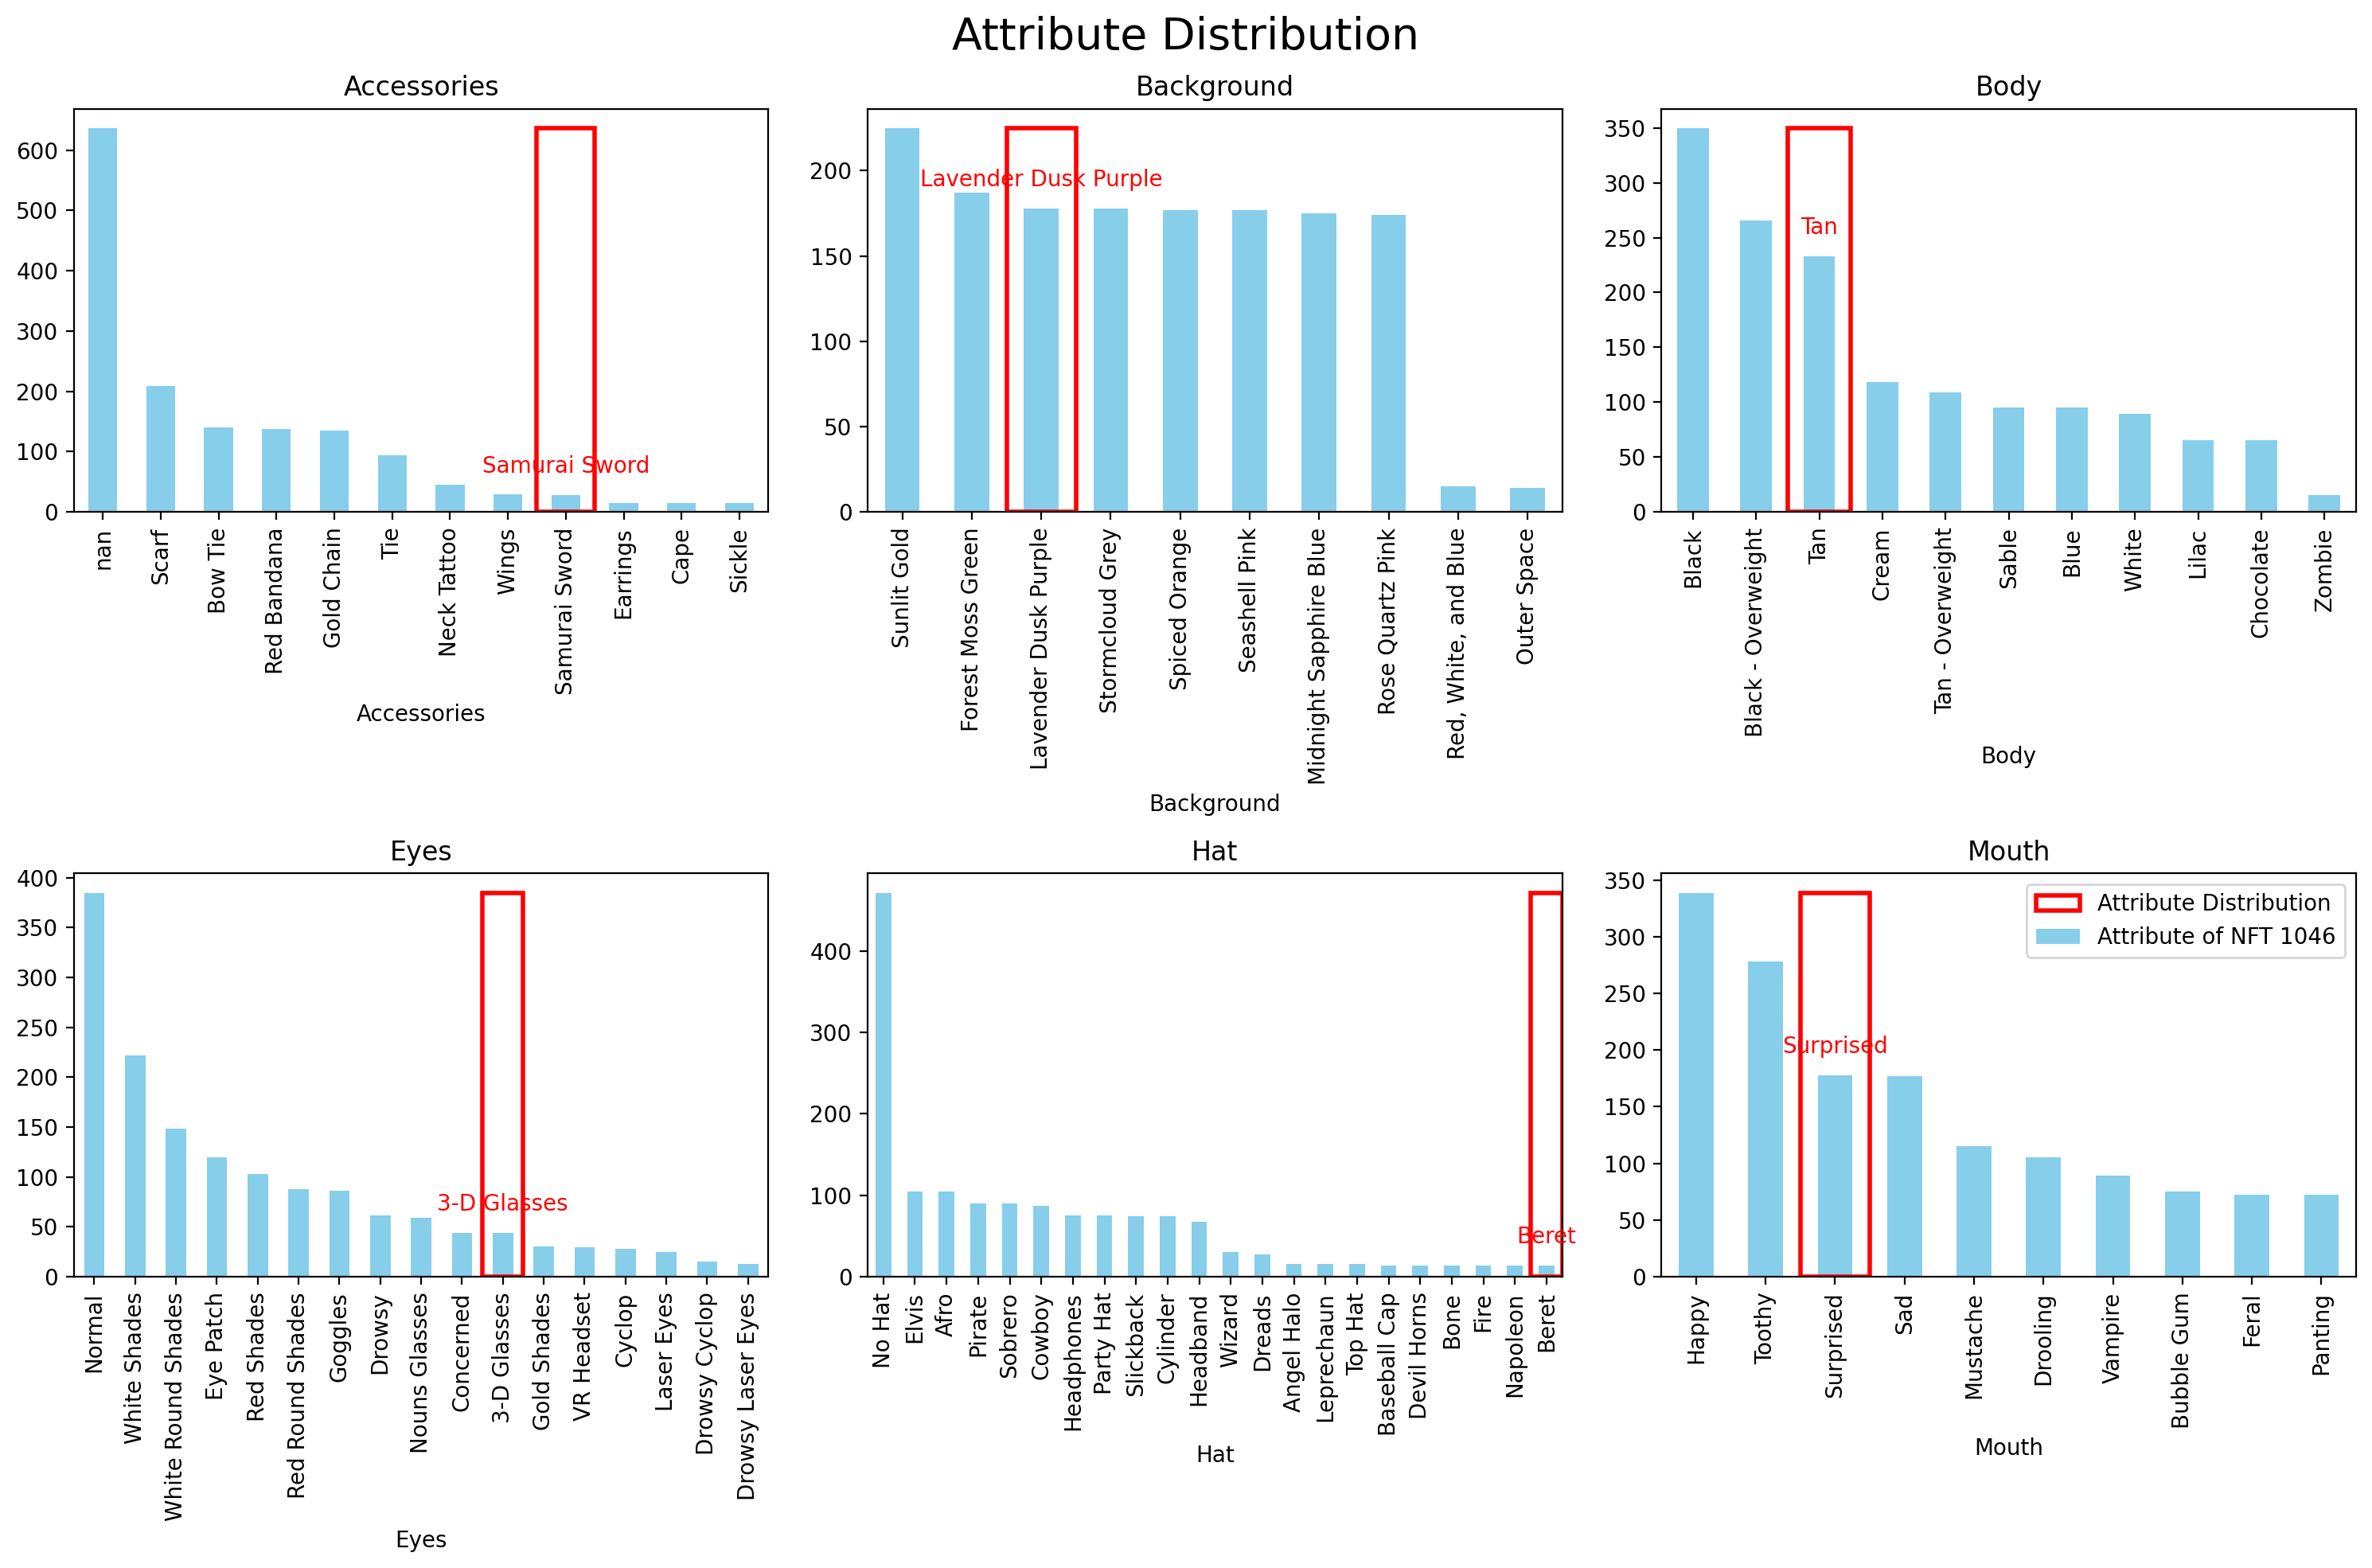

In [44]:
fig, axes = plt.subplots(2, 3, figsize=(15, 10), dpi=200)
axes = axes.flatten()

for ax, feature in zip(axes, features):
    # Plot the bar chart
    counts = attributes[feature].value_counts()
    bars = counts.plot(kind='bar', ax=ax, color='skyblue', title=feature)
    
    # Add a rectangle or annotation for the specific attribute
    if feature in attributes_1046:
        specific_attr = attributes_1046[feature]
        if specific_attr in counts:
            # Get the position of the specific attribute bar
            idx = counts.index.get_loc(specific_attr)
            rect = patches.Rectangle(
                (idx - 0.5, 0), 1, counts.max(),  # Adjust coordinates to fit the bar
                linewidth=2,
                edgecolor='red',
                facecolor='none'
            )
            ax.add_patch(rect)
            # Optional: Annotate the specific bar
            ax.annotate(
                specific_attr,
                (idx, counts[specific_attr]),
                textcoords="offset points",
                xytext=(0,10),
                ha='center',
                color='red'
            )
# add a label so we understand the red box is the attribute of the nft 1046
plt.suptitle('Attribute Distribution', fontsize=20)
plt.legend(['Attribute Distribution', 'Attribute of NFT 1046'], loc='upper right')
plt.savefig('img/1D_map.png')
plt.tight_layout()
plt.show()

In [8]:
normalized_freq_dict = {}

for feature in features:
    value_counts = attributes[feature].value_counts(normalize=True).round(4)
    normalized_freq_dict[feature] = value_counts.to_dict()

normalized_freq_dict

{'Accessories': {'nan': 0.4247,
  'Scarf': 0.1393,
  'Bow Tie': 0.0933,
  'Red Bandana': 0.092,
  'Gold Chain': 0.09,
  'Tie': 0.0627,
  'Neck Tattoo': 0.03,
  'Wings': 0.0193,
  'Samurai Sword': 0.0187,
  'Earrings': 0.01,
  'Cape': 0.01,
  'Sickle': 0.01},
 'Background': {'Sunlit Gold': 0.15,
  'Forest Moss Green': 0.1247,
  'Lavender Dusk Purple': 0.1187,
  'Stormcloud Grey': 0.1187,
  'Spiced Orange': 0.118,
  'Seashell Pink': 0.118,
  'Midnight Sapphire Blue': 0.1167,
  'Rose Quartz Pink': 0.116,
  'Red, White, and Blue': 0.01,
  'Outer Space': 0.0093},
 'Body': {'Black': 0.2333,
  'Black - Overweight': 0.1773,
  'Tan': 0.1553,
  'Cream': 0.0787,
  'Tan - Overweight': 0.0727,
  'Sable': 0.0633,
  'Blue': 0.0633,
  'White': 0.0593,
  'Lilac': 0.0433,
  'Chocolate': 0.0433,
  'Zombie': 0.01},
 'Eyes': {'Normal': 0.2567,
  'White Shades': 0.148,
  'White Round Shades': 0.0987,
  'Eye Patch': 0.08,
  'Red Shades': 0.0687,
  'Red Round Shades': 0.0587,
  'Goggles': 0.0573,
  'Drowsy': 

In [61]:
pair_frequencies = {}

for pair in pairs:
    attr1, attr2 = pair
    counts = attributes.groupby([attr1, attr2]).size().reset_index(name='count')
    
    total_count = counts['count'].sum()
    counts['probability'] = (counts['count'] / total_count).round(4)
    
    prob_dict = counts.set_index([attr1, attr2])['probability'].to_dict()
    
    pair_frequencies[tuple(pair)] = prob_dict

pair_frequencies

{('Accessories', 'Background'): {('Bow Tie', 'Forest Moss Green'): 0.0147,
  ('Bow Tie', 'Lavender Dusk Purple'): 0.01,
  ('Bow Tie', 'Midnight Sapphire Blue'): 0.0067,
  ('Bow Tie', 'Outer Space'): 0.0007,
  ('Bow Tie', 'Red, White, and Blue'): 0.0007,
  ('Bow Tie', 'Rose Quartz Pink'): 0.0093,
  ('Bow Tie', 'Seashell Pink'): 0.0127,
  ('Bow Tie', 'Spiced Orange'): 0.0133,
  ('Bow Tie', 'Stormcloud Grey'): 0.012,
  ('Bow Tie', 'Sunlit Gold'): 0.0133,
  ('Cape', 'Forest Moss Green'): 0.0007,
  ('Cape', 'Lavender Dusk Purple'): 0.0013,
  ('Cape', 'Outer Space'): 0.0007,
  ('Cape', 'Rose Quartz Pink'): 0.0007,
  ('Cape', 'Seashell Pink'): 0.0013,
  ('Cape', 'Spiced Orange'): 0.0007,
  ('Cape', 'Stormcloud Grey'): 0.002,
  ('Cape', 'Sunlit Gold'): 0.0027,
  ('Earrings', 'Forest Moss Green'): 0.0013,
  ('Earrings', 'Midnight Sapphire Blue'): 0.0013,
  ('Earrings', 'Rose Quartz Pink'): 0.002,
  ('Earrings', 'Seashell Pink'): 0.0007,
  ('Earrings', 'Spiced Orange'): 0.0013,
  ('Earrings', 'S

In [71]:
def get_pair_frequency(row):
    val1 = row[attr1]
    val2 = row[attr2]
    return pair_frequencies[tuple(pair)].get((val1, val2), 0)

db = attributes.copy()

for pair in pairs:
    attr1, attr2 = pair    
    
    df[attr1+'_freq'] = df[attr1].apply(lambda x: normalized_freq_dict[attr1][x])
    df[attr2+'_freq'] = df[attr2].apply(lambda x: normalized_freq_dict[attr2][x])

    df[f'{attr1}_{attr2}_freq'] = df.apply(get_pair_frequency, axis=1)
    
    
    db[attr1+'_freq'] = df[attr1].apply(lambda x: normalized_freq_dict[attr1][x])
    db[attr2+'_freq'] = df[attr2].apply(lambda x: normalized_freq_dict[attr2][x])

    db[f'{attr1}_{attr2}_freq'] = df.apply(get_pair_frequency, axis=1)
    

df.to_csv('data/fit_frenchie_trades_attributes_freq.csv', index=False)

In [70]:
db[db['nft_id'] == 1046]

,nft_id,Accessories,Background,Body,Eyes,Hat,Mouth,Accessories_freq,Background_freq,Accessories_Background_freq,Body_freq,Accessories_Body_freq,Eyes_freq,Accessories_Eyes_freq,Hat_freq,Accessories_Hat_freq,Mouth_freq,Accessories_Mouth_freq,Background_Body_freq,Background_Eyes_freq,Background_Hat_freq,Background_Mouth_freq,Body_Eyes_freq,Body_Hat_freq,Body_Mouth_freq,Eyes_Hat_freq,Eyes_Mouth_freq,Hat_Mouth_freq
1046,1046,Samurai Sword,Lavender Dusk Purple,Tan,3-D Glasses,Beret,Surprised,0.0933,0.116,0.0093,0.1553,0.018,0.08,0.0093,0.3147,0.0307,0.05,0.004,0.018,0.014,0.0407,0.0047,0.0113,0.048,0.008,0.0267,0.0053,0.0107


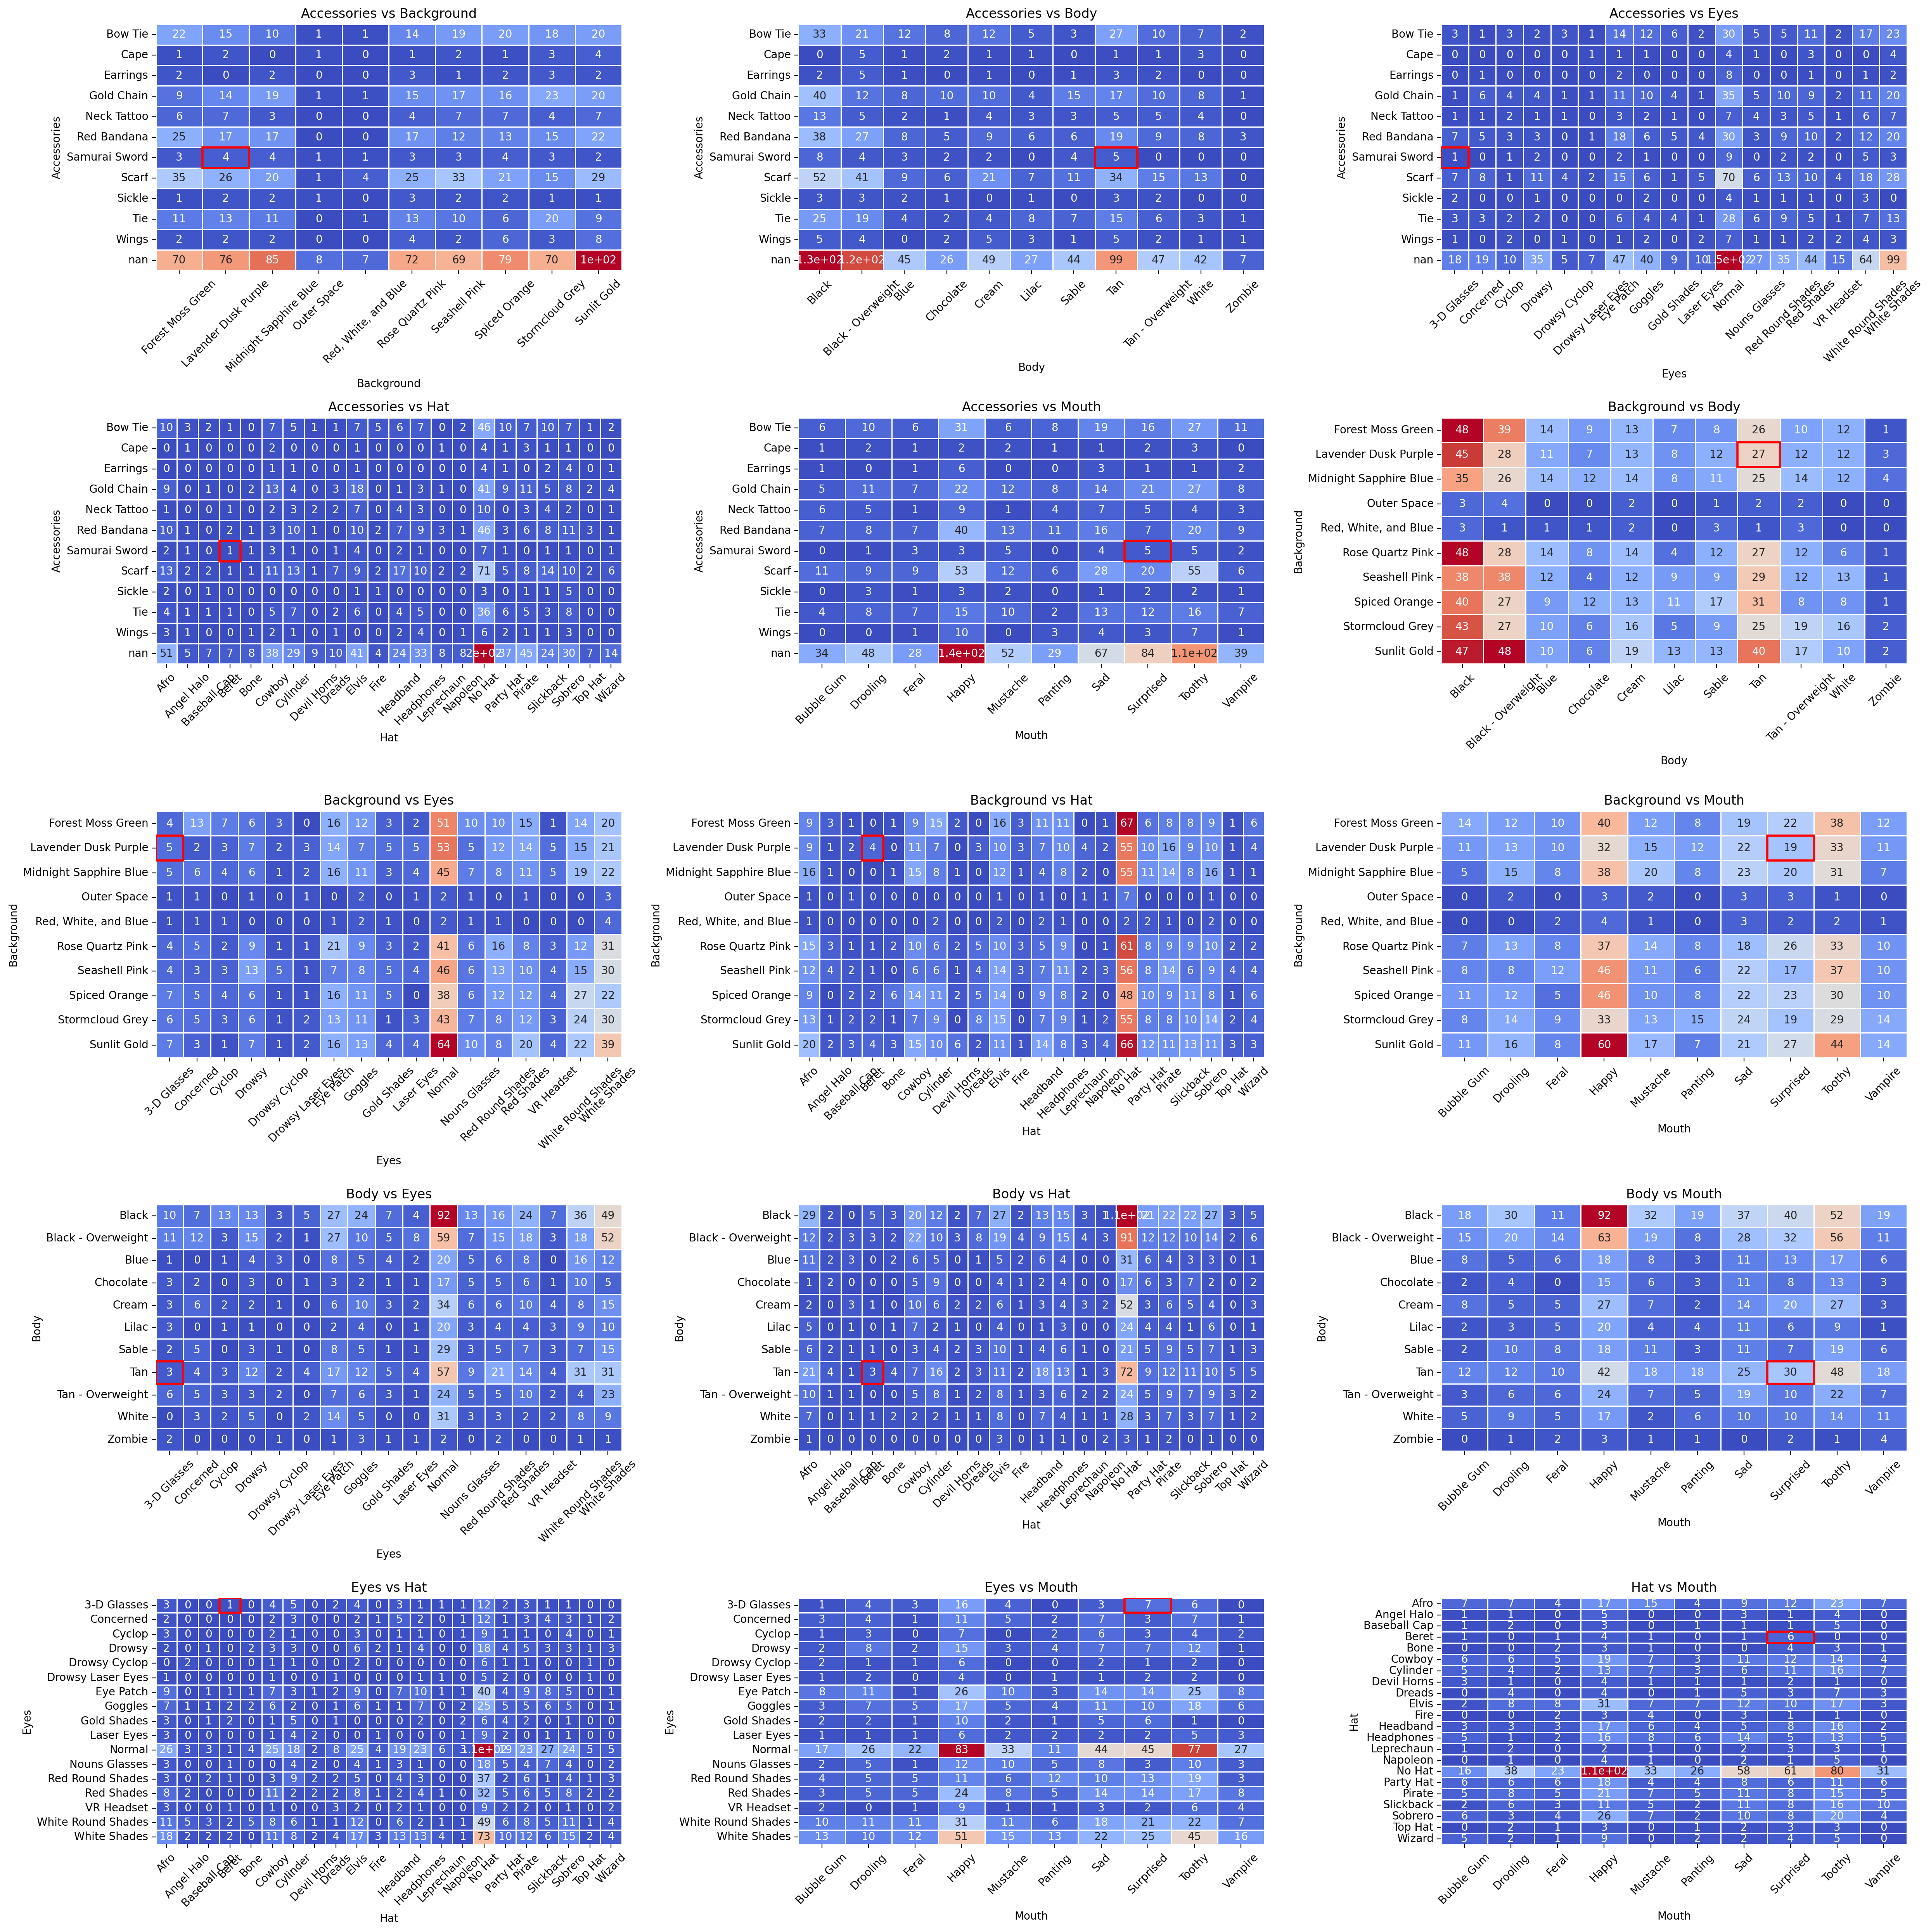

In [45]:
import matplotlib.patches as patches

features = ['Accessories', 'Background', 'Body', 'Eyes', 'Hat', 'Mouth']
pairs = [[features[i], features[j]] for i in range(len(features)) for j in range(i+1, len(features))]

fig, axes = plt.subplots(nrows=5, ncols=3, figsize=(25, 25), dpi=200)
axes = axes.flatten()

for ax, pair in zip(axes, pairs):
    sub = attributes.groupby(pair).size().reset_index(name='count')
    sub = sub.pivot(index=pair[0], columns=pair[1], values='count')
    sub = sub.fillna(0)
    
    sns.heatmap(sub, annot=True, cmap='coolwarm', ax=ax, cbar=False, linewidths=0.5)
    ax.set_title(f"{pair[0]} vs {pair[1]}")
    ax.set_xticklabels(ax.get_xticklabels(), rotation=45)
    ax.set_xlabel(pair[1])
    ax.set_ylabel(pair[0])
    
    # Draw rectangles around the feature in attributes_1046
    if pair[0] in attributes_1046 and pair[1] in attributes_1046:
        x_label = attributes_1046[pair[1]]
        y_label = attributes_1046[pair[0]]
        
        if x_label in sub.columns and y_label in sub.index:
            x = sub.columns.get_loc(x_label)
            y = sub.index.get_loc(y_label)
            
            # Add a rectangle patch around the specified cell
            rect = patches.Rectangle(
                (x, y), 1, 1,
                linewidth=2,
                edgecolor='red',
                facecolor='none'
            )
            ax.add_patch(rect)

plt.savefig('img/2D_map.png')
plt.tight_layout()
plt.show()

In [ ]:
df